# Human population genetics analysis pipeline

Pipeline to extract, process and analyze information on the human population genetics of rare codon patches and matched backgrounds.

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pybedtools
from scipy.stats import zscore, fisher_exact, spearmanr, ttest_rel, ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import gzip
import subprocess
import ast
from pathlib import Path
from scipy.stats import sem
import itertools
from scipy.stats import entropy, ks_2samp, chi2_contingency
from scipy.special import betaln

In [ ]:
# directory with bed files (can substitute)
directory = '/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/bed_files_july_2026'

# dict to store bed files
dfs_bed_for_intersection = {}

for filename in os.listdir(directory):
    if filename.endswith('.bed'):
        file_path = os.path.join(directory, filename)

        df = pd.read_csv(file_path, delimiter='\t', header=None)

        key = os.path.splitext(filename)[0]
        key = key.replace("-Jacob’s MacBook Pro", "")

        if key == 'rare_patches':
            key = 'df_bed_rare'  # specific fix to update form

        dfs_bed_for_intersection[key] = df

for key, df in dfs_bed_for_intersection.items():
    print(f"loaded {key} with shape {df.shape}")

In [ ]:
# master df of rare codon patches and relevant info (can substitute)
df_master = pd.read_csv('/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/df_master_v5.csv')

# looks up kmer id from gene
lookup_common_rare = dict(zip(df_master['gene'], df_master['meta_kmer_id']))

# df of id conversions from common to ensg id (to look it up) (can substitute)
df_id_conversions = pd.read_csv('/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/id_conversion_hg.csv')
lookup_common_name = dict(zip(df_id_conversions['name'], df_id_conversions['initial_alias']))

# defines RCPGs
RCPGs = list(set(df_master['gene'].dropna()))

In [ ]:
for key, df in dfs_bed_for_intersection.items():
    if key == 'between_genes':
        # for the between_genes set, use the host gene name (for consistency)
        dfs_bed_for_intersection[key]['gene'] = df[3].str.extract(r'from__([A-Z0-9]+)', expand=False)
    else:
        # split on '_' and take the first part
        dfs_bed_for_intersection[key]['gene'] = df[3].str.split('_').str[0]

# gets the coordinates for each kmer of a gene in the bed file (one gene may have multiple kmers)
def lookup_kmer_coords(gene, df_coords):
    # gets the ensg name from a common name
    ensg_name = lookup_common_name[gene]

    # get kmers associated with that gene
    kmer_rows = df_coords[df_coords['gene'] == ensg_name]

    if kmer_rows.empty:
        return None

    # extract all coords associated with those k-mers
    coord_list = [
        (str(row[0]), str(row[1]), str(row[2]))
        for row in kmer_rows.itertuples(index=False)
    ]

    return coord_list

In [ ]:
# parse the list of values to ensure correct data type
def parse_list(x, conv=str):
    if pd.isna(x):
        return []
    return [
        float("-inf") if i == "-inf"
        else np.nan if i == "" and conv == float
        else None if i == "" and conv == str
        else conv(i)
        for i in str(x).split(",")
    ]

# runs a query on the dbDNP bigbed file for a gene; fetches variants overlapping a set of genomic coordinates
def run_bigbed_query_for_gene(gene, df_coords, mutation_type):  # mutation type can be indels or SNV

    # the coords for a kmer come from the bed file we supplied
    coord_list = lookup_kmer_coords(gene, df_coords)
    if not coord_list:
        print(f"no coordinates found for gene: {gene}")
        empty_cols = [
            "chrom", "chromStart", "chromEnd", "name", "ref", "altCount", "alts", "shiftBases",
            "freqSourceCount", "minorAlleleFreq", "majorAllele", "minorAllele",
            "maxFuncImpact", "class", "ucscNotes", "_dataOffset", "_dataLen",
            "max_allele_freq", "max_allele_freq_idx", "argmax_minor_allele", "diff", "diff_mod_3",
            "is_rare_variant", "region_id", "region_coords", "n_regions_queried", "n_regions_with_variants"
        ]
        return pd.DataFrame(columns=empty_cols)
    # can substiute output dir
    output_dir = "/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/bed_files_july_2026"
    os.makedirs(output_dir, exist_ok=True)

    dfs = []
    n_regions_with_hits = 0  # count of regions that produced hits

    # makes a call for each kmer associated with a given gene
    for idx, (chr_, start, end) in enumerate(coord_list):
        start = int(start)
        end = int(end)

        output_file = os.path.join(output_dir, f"{gene}_region{idx}_{mutation_type}.bed")

        # queries using 'bigBedToBed'; requires the bigbed file (can substitute the path)
        cmd = (
            f"/home/blencowe/blencowe4/jfine/.conda/envs/jlfconda/envs/jlf_conda_march/bin/bigBedToBed "
            f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/dbSnp155.bb.1 stdout "
            f"-chrom={chr_} -start={start} -end={end} | "
            f"awk -F'\t' '$14 == \"{mutation_type}\"' > {output_file}"
        )

        # runs that as a subprocess
        subprocess.run(cmd, shell=True, check=True)

        # sometimes no variant is found for the region
        if os.path.getsize(output_file) == 0:
            print(f"no {mutation_type} variants found for {gene} in region {chr_}:{start}-{end}")
            continue

        n_regions_with_hits += 1  # updates count if variants found

        df = pd.read_csv(output_file, sep='\t', header=None, dtype=str)

        # col names as determined from ucsc
        df.columns = [
            "chrom", "chromStart", "chromEnd", "name", "ref", "altCount", "alts", "shiftBases",
            "freqSourceCount", "minorAlleleFreq", "majorAllele", "minorAllele",
            "maxFuncImpact", "class", "ucscNotes", "_dataOffset", "_dataLen"
        ]

        # ensures data types are correct
        df["chromStart"] = df["chromStart"].astype(int)
        df["chromEnd"] = df["chromEnd"].astype(int)
        df["altCount"] = df["altCount"].astype(int)
        df["shiftBases"] = df["shiftBases"].astype(int)
        df["freqSourceCount"] = df["freqSourceCount"].astype(int)
        df["minorAlleleFreq"] = df["minorAlleleFreq"].apply(lambda x: parse_list(x, float))
        df["majorAllele"] = df["majorAllele"].apply(lambda x: parse_list(x, str))
        df["minorAllele"] = df["minorAllele"].apply(lambda x: parse_list(x, str))
        df["ucscNotes"] = df["ucscNotes"].apply(lambda x: parse_list(x, str))
        df["maxFuncImpact"] = df["maxFuncImpact"].astype(int)
        df["_dataOffset"] = df["_dataOffset"].astype(int)
        df["_dataLen"] = df["_dataLen"].astype(int)
        df["region_id"] = idx
        df["region_coords"] = f"{chr_}:{start}-{end}"

        dfs.append(df)  # stores results from querying variants for that region

    if not dfs:
        print(f"no {mutation_type} variants found in any region for gene: {gene}")
        return pd.DataFrame(columns=[
            "chrom", "chromStart", "chromEnd", "name", "ref", "altCount", "alts", "shiftBases",
            "freqSourceCount", "minorAlleleFreq", "majorAllele", "minorAllele",
            "maxFuncImpact", "class", "ucscNotes", "_dataOffset", "_dataLen",
            "max_allele_freq", "max_allele_freq_idx", "argmax_minor_allele", "diff", "diff_mod_3",
            "is_rare_variant", "region_id", "region_coords", "n_regions_queried", "n_regions_with_variants"
        ])

    # concats all the region dfs for this gene
    df = pd.concat(dfs, ignore_index=True)

    # max minor allele frequency
    df['max_allele_freq'] = df['minorAlleleFreq'].apply(
        lambda freqs: np.nanmax(freqs) if isinstance(freqs, list) and freqs else np.nan
    )

    # index of the max minor allele frequency
    df['max_allele_freq_idx'] = df['minorAlleleFreq'].apply(
        lambda freqs: int(np.nanargmax(freqs)) if isinstance(freqs, list) and freqs and not all(pd.isna(freqs)) else np.nan
    )

    # the minor allele with the max maf
    df['argmax_minor_allele'] = df.apply(
        lambda row: row['minorAllele'][int(row['max_allele_freq_idx'])]
        if isinstance(row['minorAllele'], list)
        and not pd.isna(row['max_allele_freq_idx'])
        and int(row['max_allele_freq_idx']) < len(row['minorAllele'])
        else None,
        axis=1
    )
    # drops rows with NA max allele freq
    df = df[df['max_allele_freq'].notna()]

    # adds more fields relevant to variant info
    df['diff'] = df['argmax_minor_allele'].str.len() - df['ref'].str.len()
    df['diff_mod_3'] = df['diff'] % 3
    df['is_rare_variant'] = (df['max_allele_freq'] > 0) & (df['max_allele_freq'] < 0.01)

    # tracks number of regions queried vs regions with variants
    df['n_regions_queried'] = len(coord_list)
    df['n_regions_with_variants'] = n_regions_with_hits
    df['gene'] = gene  # keeps the gene with its row

    print(f"found {len(df)} {mutation_type} variants for {gene} across {n_regions_with_hits}/{len(coord_list)} regions.")
    return df

In [ ]:
# for a list of genes, get AF info en masse
def get_gene_stats(RCPGs, df_indel, df_type=str, mutation_type=str):
    gene_stats = {}

    # iterates through each gene and queries its variants
    for gene in RCPGs:

        df_result = run_bigbed_query_for_gene(gene, dfs_bed_for_intersection[df_type], mutation_type)
        df_result_in_frame = df_result[df_result['diff_mod_3'] == 0]

        # case for when there are no results
        if df_result_in_frame.empty:
            gene_stats[gene] = {
                'gene': gene,
                'n_rare_indels': 0,
                'diff_abs': np.nan,
                'diff_mean': np.nan,
                'std_diff': np.nan,
                'allele_freqs': [],
                'allele_snp_ids': [],
                'argmax_minor_alleles': [],
                'ref_alleles': [],
                'alt_alleles': [],
                'variant_coords': [],
                'mutation_type_summary': [],
                'indel_lengths': [],
                'n_regions_queried': 0,
                'n_regions_with_variants': 0
            }
            continue

        # difference in length
        diff_abs = df_result_in_frame['diff'].abs().mean()
        diff_mean = df_result_in_frame['diff'].mean()
        diff_std = df_result_in_frame['diff'].std()

        # allele info: name, the max maf, and the associated minor alleles
        allele_names = list(df_result_in_frame['name'])
        allele_freqs_gene = list(df_result_in_frame['max_allele_freq'])
        argmax_minor_alleles = list(df_result_in_frame['argmax_minor_allele'])

        # refs and alts
        ref_alleles = list(df_result_in_frame['ref'])
        alt_alleles = [tuple(a.split(',')) if isinstance(a, str) else () for a in df_result_in_frame['alts']]

        # other allele-related quantities
        variant_coords = list(zip(
            df_result_in_frame['chrom'],
            df_result_in_frame['chromStart'],
            df_result_in_frame['chromEnd']
        ))

        mutation_type_summary = df_result_in_frame['diff'].apply(
            lambda d: 'INS' if d > 0 else ('DEL' if d < 0 else 'EQL')
        ).tolist()

        indel_lengths = df_result_in_frame['diff'].abs().tolist()

        n_regions_total = int(df_result['n_regions_queried'].iloc[0])
        n_regions_with_variants = int(df_result['n_regions_with_variants'].iloc[0])

        # stores results for each gene, based on the variants in its k-mers of interest
        gene_stats[gene] = {
            'gene': gene,
            'n_rare_indels': int((df_result_in_frame['max_allele_freq'] <= 0.01).sum()),
            'diff_abs': round(diff_abs, 4),
            'diff_mean': round(diff_mean, 4),
            'std_diff': round(diff_std, 4),
            'allele_freqs': allele_freqs_gene,
            'allele_snp_ids': allele_names,
            'argmax_minor_alleles': argmax_minor_alleles,
            'ref_alleles': ref_alleles,
            'alt_alleles': alt_alleles,
            'variant_coords': variant_coords,
            'mutation_type_summary': mutation_type_summary,
            'indel_lengths': indel_lengths,
            'n_regions_queried': n_regions_total,
            'n_regions_with_variants': n_regions_with_variants
        }

    df = pd.DataFrame.from_dict(gene_stats, orient='index')
    return df

In [ ]:
dfs_keys_to_try = list(dfs_bed_for_intersection.keys())

In [ ]:
# applies this to all the k-mer set dfs and gets their associated snps
result_dfs_snv = {}  # a dict of dicts
for key in dfs_keys_to_try:
    gene_stats_result = get_gene_stats(RCPGs, dfs_bed_for_intersection, df_type=key, mutation_type='snv')
    result_dfs_snv[key] = gene_stats_result

# approx 3 min 

In [ ]:
# saves the results fetched from the bigbed
def save_fetched_dict(df_dict, t, d):  # dict, type and date; parameters to customize save info
    # directory to save results
    save_dir = f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint"
    os.makedirs(save_dir, exist_ok=True)

    # saves each df
    for key, df in df_dict.items():
        if isinstance(df, pd.DataFrame):
            filename = f"{key}.csv"
            filepath = os.path.join(save_dir, filename)
            df.to_csv(filepath, index=False)
            print(f"saved df: {filepath}")
        else:
            print(f"skipped df for key: {key}")

In [ ]:
save_fetched_dict(result_dfs_snv, 'SNV', 'july_5_2026')

In [ ]:
# checkpoint: resume from here after saving the csvs from before
# safely evaluates reps of python literals
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# reads the csv files that were saved earlier
def read_csv_files(t, d):
    save_dir = f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint"

    list_like_columns = {
        'allele_freqs',
        'allele_snp_ids',
        'argmax_minor_alleles',
        'ref_alleles',
        'alt_alleles',
        'variant_coords',
        'mutation_type_summary',
        'indel_lengths',
    }

    # reconstructs the results based on what was saved
    reconstructed_dict = {}

    for filename in os.listdir(save_dir):
        if filename.endswith(".csv"):
            key = filename[:-4]
            filepath = os.path.join(save_dir, filename)

            preview_df = pd.read_csv(filepath, nrows=1)
            colnames = preview_df.columns

            # safely evaluate python literals (i.e., lists that store afs)
            converters = {col: safe_eval for col in colnames if col in list_like_columns}

            # loads into a df and stores it for the given kmer set
            df = pd.read_csv(filepath, converters=converters)

            reconstructed_dict[key] = df
            print(f"loaded df from {filepath}")

    return reconstructed_dict

In [ ]:
# extracts snv info from the saved checkpoints
reconstructed_dict_SNV = read_csv_files('SNV', 'july_5_2026')  # t = SNV or INDEL, d = date

# ~10 seconds

In [ ]:
# generates VSF files from the reconstructed dicts to make them ready for VEP
def write_vcfs_from_checkpoint_dict(reconstructed_dict, t, d):
    # subdirectory to save vcf files (can substitute)
    save_dir = f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint"
    vcf_dir = os.path.join(save_dir, "vcf_files")
    os.makedirs(vcf_dir, exist_ok=True)

    for key, df in reconstructed_dict.items():
        vcf_lines = [
            "##fileformat=VCFv4.2",
            '##INFO=<ID=AF,Number=1,Type=Float,Description="Max allele frequency of the minor allele">',
            '##INFO=<ID=TYPE,Number=1,Type=String,Description="Variant type inferred from allele length: INS, DEL, or SUB">',
            "#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO"
        ]

        num_variants_written = 0

        for _, row in df.iterrows():
            # parses the results from a given df in the reconstructed dict
            try:
                coords = row['variant_coords']
                rsids = row['allele_snp_ids']
                refs = row['ref_alleles']
                alts = row['argmax_minor_alleles']
                freqs = row['allele_freqs']
                mutation_types = row.get('mutation_type_summary', ['.'] * len(rsids))

                # first make sure the lists are equal length (since we convert the lists into rows)
                if not (len(coords) == len(rsids) == len(refs) == len(alts) == len(freqs) == len(mutation_types)):
                    print(f"skipping row in {key} due to mismatched list lengths.")
                    continue

                for (chrom, start, _), rsid, ref, alt, af, mtype in zip(coords, rsids, refs, alts, freqs, mutation_types):
                    if pd.isna(rsid) or pd.isna(ref) or pd.isna(alt):
                        continue

                    # writes a line in the Vcf from the same relative positions in the lists
                    pos = int(start) + 1
                    af_str = f"{float(af):.5g}" if pd.notna(af) else "."
                    mtype_str = str(mtype) if pd.notna(mtype) else "."

                    info_field = f"AF={af_str};TYPE={mtype_str}"
                    vcf_line = f"{chrom}\t{pos}\t{rsid}\t{ref}\t{alt}\t.\t.\t{info_field}"
                    vcf_lines.append(vcf_line)
                    num_variants_written += 1

            except Exception as e:
                print(f"error processing row in {key}: {e}")
                continue

        # writes the VCF
        if num_variants_written > 0:
            output_path = os.path.join(vcf_dir, f"{key}_variants.vcf")
            with open(output_path, 'w') as f:
                f.write("\n".join(vcf_lines) + "\n")
            print(f"wrote {num_variants_written} variants to {output_path}")
        else:
            print(f"no variants written for {key}")

In [ ]:
# writes the variants from the k-mer sets for SNVs
write_vcfs_from_checkpoint_dict(reconstructed_dict_SNV, t="SNV", d="july_5_2026")

In [ ]:
# Writes a job submission file to run vep on the selected vcfs 

## this will also obtain the specific codon to codon transitions!
def generate_vep_job_file_for_vcfs(t, d):
    save_dir = Path(f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint").resolve()
    vcf_dir = save_dir / "vcf_files"

    if not vcf_dir.exists():
        raise FileNotFoundError(f"vcf directory not found: {vcf_dir}")

    # output for vep results 
    output_dir = vcf_dir / "vep_outputs"
    output_dir.mkdir(exist_ok=True)

    job_dir = vcf_dir / "job_scripts"
    job_dir.mkdir(exist_ok=True)

    job_file = job_dir / "vep_jobs.txt"

    with job_file.open("w") as f:
        for vcf_file in vcf_dir.glob("*.vcf"):
            out_file = output_dir / (vcf_file.stem + "_VEP.txt")

            # the actual command for running vep
            command = (
                f"vep "
                f"--species homo_sapiens "
                f"--assembly GRCh38 "
                f"--cache "
                f"--offline "
                f"--cache_version 109 "
                f"--input_file \"{vcf_file}\" "
                f"--format vcf "
                f"--output_file \"{out_file}\" "
                f"--tab "
                f"--everything "
                f"--force_overwrite"
            )
            f.write(command + "\n")

    print(f"vep job file saved to {job_file}")
    print(f"expected vep output will go to {output_dir}")

# generates the job file for snv (to predict variant impact)
generate_vep_job_file_for_vcfs(t="SNV", d="july_5_2026")

need to then do: 

submitjob -f "/vcf_files/job_scripts/vep_jobs.txt"  



In [ ]:
# look up the af for a given rsid; extracts afs from the results
reconstructed_dict = reconstructed_dict_SNV.copy()

def extract_rs_af_dict(df):
    rs_af_dict = {}

    # safely evaluates python literals
    df['allele_snp_ids'] = df['allele_snp_ids'].apply(safe_eval)
    df['allele_freqs'] = df['allele_freqs'].apply(safe_eval)

    # writes the af for each SNP id
    for snp_list, af_list in zip(df['allele_snp_ids'], df['allele_freqs']):
        if isinstance(snp_list, list) and isinstance(af_list, list):
            for rs, af in zip(snp_list, af_list):
                rs_af_dict[rs] = af
        else:
            print(f"skipping row due to malformed list: {snp_list}, {af_list}")

    return rs_af_dict

# combines all into a dict to look up the AF for a given rsid
combined_rs_af_dict = {}

for key, df in reconstructed_dict.items():
    if 'allele_snp_ids' in df.columns and 'allele_freqs' in df.columns:
        rs_af = extract_rs_af_dict(df)
        combined_rs_af_dict.update(rs_af)

print(f"total unique rsids extracted: {len(combined_rs_af_dict)}")

In [ ]:
# maps each rsid to its host gene
rsid_dict = {
    key: [rsid for row in df['allele_snp_ids'].dropna() for rsid in row]
    for key, df in reconstructed_dict.items()
}
# # to tell which gene each rsID is from
rs_to_gene = {}
for key, df in reconstructed_dict.items():
    dict_df_rsid_to_gene = dict(zip(df['gene'], df['allele_snp_ids']))
    rs_to_gene[key] = dict_df_rsid_to_gene

lookup_rs_to_gene = {}
for key_1, dict_1 in rs_to_gene.items():  # one dict per df
    for gene, rs_list_gene in dict_1.items():  # genes paired with rsid lists 
        for rsid in rs_list_gene:  # each rsid maps to its host gene
            lookup_rs_to_gene[rsid] = gene

In [ ]:
# loads the vep results that ran on the cluster
def load_vep_outputs_as_dict(t, d):
    # relevant directories 
    save_dir = f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint"
    vep_dir = os.path.join(save_dir, "vcf_files", "vep_outputs")

    # dict of the vep files
    vep_dict = {}

    for file in os.listdir(vep_dir):
        # extracts the relevant file names
        if file.endswith("_VEP.txt"):
            try:
                key = file.split("_variants")[0]
                file_path = os.path.join(vep_dir, file)

                # finds the header line (starts with "#Uploaded_variation") so cols are formatted properly
                with open(file_path, 'r') as f:
                    for i, line in enumerate(f):
                        if line.startswith("#Uploaded_variation"):
                            header_line_num = i
                            break

                df = pd.read_csv(file_path, sep="\t", header=header_line_num)
                vep_dict[key] = df
                print(f"loaded {file} from key {key} with ({df.shape[0]} rows)")

            except Exception as e:
                print(f"failed to load {file}: {e}")

    return vep_dict

In [ ]:
# loads the vep results for a given mutation type and date
vep_dict = load_vep_outputs_as_dict(t="SNV", d="july_5_2026")

In [ ]:
# df with longest orfs (can substitute)
df_longest_orfs = pd.read_csv("/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_all/gencode_v43_longest_orfs_assembled_nov_29-Jacob’s MacBook Pro.csv")

# transcript ids of the longest transcripts, to subset before analysis
longest_transcripts = list(set(df_longest_orfs['transcript'].str.split('.').str[0]))

# types of variants to filter by
types_of_variants = ['missense_variant', 'synonymous_variant']

In [ ]:
# combines all the dfs and subsets to the longest orfs
dfs = []

# loops over the dict of vep results
for key, df in vep_dict.items():
    df = df.copy()
    df['source_key'] = key  # tags the key the df came from (for the concat)

    # subset to the cases we care about (syn/missense variants in longest transcripts)
    df = df[df['Consequence'].isin(types_of_variants)]
    df = df[df['Feature'].isin(longest_transcripts)]

    dfs.append(df)

# joins all the dfs
combined_df = pd.concat(dfs, ignore_index=True)

# looks up the associated AF from the bigbed, for that variant
combined_df['dbSNP_AF'] = combined_df['#Uploaded_variation'].map(combined_rs_af_dict)

print(f"combined {len(dfs)} dataframes with {combined_df.shape[0]} total rows.")

In [ ]:
# saves combined_df if necessary
def save_combined_df_to_csv(combined_df, t, d):
    # directory to save in (can substitute)
    save_dir = f"/home/blencowe/blencowe4/jfine/Mar_2025/human_snpdb_checkpoints/{t}s_{d}_checkpoint/combined_df"
    os.makedirs(save_dir, exist_ok=True)

    output_path = os.path.join(save_dir, "combined_df.csv")
    combined_df.to_csv(output_path, index=False)
    print(f"saved combined_df to {output_path}")

save_combined_df_to_csv(combined_df, t="SNV", d="july_5_2026")

In [26]:
# (can start here while working locally)
import pandas as pd
combined_df = pd.read_csv("/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/notebooks/scratch/human_gen_july_5_2026/combined_df.csv")

In [27]:
# tags each variant with its k-mer set and high-level group
combined_df['kmer_set'] = combined_df['source_key'].copy()
combined_df['GROUP'] = 'other'  # default value
combined_df.loc[combined_df['kmer_set'].str.contains('within'), 'GROUP'] = 'RCPGs' ## within genes
combined_df.loc[combined_df['kmer_set'].str.contains('between'), 'GROUP'] = 'all_genes' ## between genes
combined_df.loc[combined_df['kmer_set'] == 'df_bed_rare', 'GROUP'] = 'rare'

In [28]:
# gets the codon substitution matrix for a given k-mer set
types_of_variants = ['missense_variant', 'synonymous_variant']

def get_subst_matrix(kmer_set):
    # subsets combined_df to the cases of interest
    combined_df_syn_asyn = combined_df[combined_df['Consequence'].isin(types_of_variants)]
    combined_df_syn_asyn = combined_df_syn_asyn[combined_df_syn_asyn['kmer_set'] == kmer_set]
    codon_changes = list(combined_df_syn_asyn['Codons'])
    codon_changes = [c.upper() for c in codon_changes]

    # generates all possible codons
    bases = ['A', 'T', 'C', 'G']
    codons = [''.join(c) for c in itertools.product(bases, repeat=3)]

    # initializes an empty substitution matrix
    sub_matrix = pd.DataFrame(0, index=codons, columns=codons)

    # fills the matrix by counting codon to codon mutations
    for change in codon_changes:
        ref, alt = change.split('/')
        if ref in codons and alt in codons:
            sub_matrix.loc[ref, alt] += 1
    return sub_matrix

In [29]:
# renames the kmer_set column to the high-level group label
combined_df['kmer_set'] = combined_df['GROUP'].copy()

In [30]:
# defines the codon sets
bases = ['A', 'T', 'C', 'G']

all_codons = []
for base_1 in bases:
    for base_2 in bases:
        for base_3 in bases:
            all_codons.append(base_1 + base_2 + base_3)

rare_codons = ['TCG', 'CGT', 'ACG', 'CGA', 'CCG', 'GTA', 'CTA', 'GCG', 'ATA', 'TTA']
common_codons = [codon for codon in all_codons if codon not in rare_codons]

In [31]:
# genetic code dict
genetic_code = {
    'ATA': 'I', 'ATC': 'I', 'ATT': 'I', 'ATG': 'M',
    'ACA': 'T', 'ACC': 'T', 'ACG': 'T', 'ACT': 'T',
    'AAC': 'N', 'AAT': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGC': 'S', 'AGT': 'S', 'AGA': 'R', 'AGG': 'R',
    'CTA': 'L', 'CTC': 'L', 'CTG': 'L', 'CTT': 'L',
    'CCA': 'P', 'CCC': 'P', 'CCG': 'P', 'CCT': 'P',
    'CAC': 'H', 'CAT': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGA': 'R', 'CGC': 'R', 'CGG': 'R', 'CGT': 'R',
    'GTA': 'V', 'GTC': 'V', 'GTG': 'V', 'GTT': 'V',
    'GCA': 'A', 'GCC': 'A', 'GCG': 'A', 'GCT': 'A',
    'GAC': 'D', 'GAT': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGA': 'G', 'GGC': 'G', 'GGG': 'G', 'GGT': 'G',
    'TCA': 'S', 'TCC': 'S', 'TCG': 'S', 'TCT': 'S',
    'TTC': 'F', 'TTT': 'F', 'TTA': 'L', 'TTG': 'L',
    'TAC': 'Y', 'TAT': 'Y', 'TAA': '*', 'TAG': '*',
    'TGC': 'C', 'TGT': 'C', 'TGA': '*', 'TGG': 'W'}

In [32]:
# labels each codon-to-codon transition as RR, RC, CR, or CC based on whether the initial/final codon is rare or common
types_of_variants = ['missense_variant', 'synonymous_variant']
variants_to_consider = types_of_variants

combined_df_syn_asyn = combined_df[combined_df['Consequence'].isin(variants_to_consider)]

combined_df_syn_asyn[['initial_codon', 'final_codon']] = (
    combined_df_syn_asyn['Codons']
    .str.upper()
    .str.split('/', expand=True)
)

combined_df_syn_asyn['codon_i'] = combined_df_syn_asyn['initial_codon'].apply(
    lambda x: 'R' if x in rare_codons else 'C'
)

combined_df_syn_asyn['codon_j'] = combined_df_syn_asyn['final_codon'].apply(
    lambda x: 'R' if x in rare_codons else 'C'
)

combined_df_syn_asyn['transition_ij'] = combined_df_syn_asyn['codon_i'] + combined_df_syn_asyn['codon_j']

In [33]:
# gets the AF distribution for each transition type
combined_df_syn_asyn_ALLELE_VALID = combined_df_syn_asyn

combined_df_syn_asyn_ALLELE_VALID['dbSNP_AF'] = pd.to_numeric(combined_df_syn_asyn_ALLELE_VALID['dbSNP_AF'], errors='coerce')

def get_AF_distribution_matrix(kmer_set=None, consequence_type=None):
    df = combined_df_syn_asyn_ALLELE_VALID.copy()

    # optional filtering by k-mer set
    if kmer_set is not None:
        df = df[df['kmer_set'] == kmer_set]

    # optional filtering by consequence type
    if consequence_type:
        df = df[df['Consequence'] == consequence_type]

    # builds the af distribution matrix
    af_distribution_matrix = (
        df
        .groupby(['codon_i', 'codon_j'])['dbSNP_AF']
        .apply(list)
        .unstack(fill_value=np.nan)
    )

    return af_distribution_matrix

In [34]:
combined_df_syn_asyn_ALLELE_VALID

,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,...,TRANSCRIPTION_FACTORS,source_key,dbSNP_AF,kmer_set,GROUP,initial_codon,final_codon,codon_i,codon_j,transition_ij
0,rs755281403,chr5:160092726,T,ENSG00000170234,ENST00000307063,Transcript,missense_variant,1986,1924,642,...,-,within_genes,0.000259,RCPGs,RCPGs,GTC,ATC,C,C,CC
1,rs1397533590,chr5:160092727,A,ENSG00000170234,ENST00000307063,Transcript,synonymous_variant,1985,1923,641,...,-,within_genes,0.000020,RCPGs,RCPGs,AAC,AAT,C,C,CC
2,rs1310334330,chr5:160092740,T,ENSG00000170234,ENST00000307063,Transcript,missense_variant,1972,1910,637,...,-,within_genes,0.000007,RCPGs,RCPGs,GTC,GAC,C,C,CC
3,rs781471964,chr5:160092741,T,ENSG00000170234,ENST00000307063,Transcript,missense_variant,1971,1909,637,...,-,within_genes,0.000519,RCPGs,RCPGs,GTC,ATC,C,C,CC
4,rs1228067315,chr5:160092742,C,ENSG00000170234,ENST00000307063,Transcript,synonymous_variant,1970,1908,636,...,-,within_genes,0.000007,RCPGs,RCPGs,AAA,AAG,C,C,CC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56106,rs758583731,chr19:900100,T,ENSG00000198858,ENST00000361574,Transcript,synonymous_variant,584,522,174,...,-,between_genes,0.000017,all_genes,all_genes,CGG,CGA,C,R,CR
56107,rs777666939,chr19:900101,T,ENSG00000198858,ENST00000361574,Transcript,missense_variant,583,521,174,...,-,between_genes,0.000447,all_genes,all_genes,CGG,CAG,C,C,CC
56108,rs747079024,chr19:900102,A,ENSG00000198858,ENST00000361574,Transcript,missense_variant,582,520,174,...,-,between_genes,0.000026,all_genes,all_genes,CGG,TGG,C,C,CC
56109,rs147694333,chr19:900110,T,ENSG00000198858,ENST00000361574,Transcript,missense_variant,574,512,171,...,-,between_genes,0.000077,all_genes,all_genes,CGC,CAC,C,C,CC


In [35]:
# subset to synonymous variants with nonzero AF and keep the relevant columns 
# (we dont need most columns and there are many)
combined_df_syn_asyn_ALLELE_VALID_syn = combined_df_syn_asyn_ALLELE_VALID[
    combined_df_syn_asyn_ALLELE_VALID['Consequence'] == 'synonymous_variant'
]
combined_df_syn_asyn_ALLELE_VALID_syn = combined_df_syn_asyn_ALLELE_VALID_syn[
    combined_df_syn_asyn_ALLELE_VALID_syn['dbSNP_AF'] != 0
]

cols_to_keep = [
    "#Uploaded_variation",
    "dbSNP_AF",
    "kmer_set",
    "GROUP",
    "initial_codon",
    "final_codon",
    "codon_i",
    "codon_j",
    "transition_ij"
]

combined_df_syn_asyn_ALLELE_VALID_syn = combined_df_syn_asyn_ALLELE_VALID_syn[cols_to_keep].copy()

In [36]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [37]:
%R -i combined_df_syn_asyn_ALLELE_VALID_syn

[1] "Fisher's exact test results:"
            Transition        Comparison n_common_patch n_rare_patch
odds ratio          CR rare vs all_genes             49          487
odds ratio1         CR     rare vs RCPGs             49          487
odds ratio2         CC rare vs all_genes            105         1348
odds ratio3         CC     rare vs RCPGs            105         1348
            n_common_bg n_rare_bg p_common_patch p_common_bg odds_ratio
odds ratio          110      2088     0.09141791  0.05004550   1.909442
odds ratio1          24       479     0.09141791  0.04771372   2.006812
odds ratio2         449      6974     0.07226428  0.06048767   1.209832
odds ratio3         149      1977     0.07226428  0.07008467   1.033532
                 p_value  neg_log_p
odds ratio  0.0006099091 3.21473486
odds ratio1 0.0072116181 2.14196728
odds ratio2 0.0966424282 1.01483217
odds ratio3 0.8424260907 0.07446819
[1] "results saved to csv"


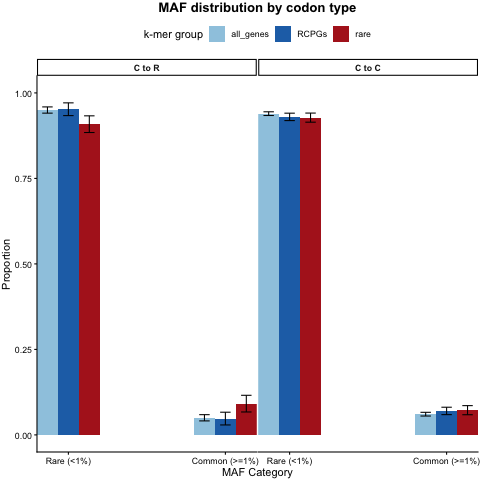

In [38]:
%%R
## to visualize the MAF distributino of codon transitions of interest for different kmer sets
library(ggplot2)
library(gridExtra)

# close any leftover graphics devices from earlier runs (avoids unsaved/empty pdfs)
# graphics.off()

# output directory
output_dir <- "/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/outputs/figures/figure_4/human_genetics"
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

df <- combined_df_syn_asyn_ALLELE_VALID_syn
df$type_of_allele <- ifelse(df$dbSNP_AF > 0.01, 'common_var', 'rare_var')
df <- df[df$transition_ij %in% c('CC', 'CR'), ]
df <- df[df$kmer_set %in% c('all_genes', 'RCPGs', 'rare'), ]

# fthe maf distribution (rare vs common alleles)
bins_edges <- c(0, 0.01, Inf)
labels <- c("Rare (<1%)", "Common (>=1%)")
df$bin <- cut(df$dbSNP_AF, breaks = bins_edges, labels = labels, right = FALSE)

# subsets the MAFs by kmer set and codon transition type
summ_list <- list()
counter <- 1
for (k in c('all_genes', 'RCPGs', 'rare')) {
  for (t in c('CC', 'CR')) {
    for (b in labels) {
      n <- sum(df$kmer_set == k & df$transition_ij == t & df$bin == b, na.rm = TRUE)
      summ_list[[counter]] <- data.frame(
        kmer_set = k,
        transition_ij = t,
        bin = b,
        n_bin = n,
        stringsAsFactors = FALSE
      )
      counter <- counter + 1
    }
  }
}

df_summ <- do.call(rbind, summ_list)
rownames(df_summ) <- NULL

# calculate proportions in different sets
for (i in 1:nrow(df_summ)) {
  tot <- sum(df_summ$n_bin[df_summ$kmer_set == df_summ$kmer_set[i] &
                             df_summ$transition_ij == df_summ$transition_ij[i]])
  df_summ$n_total[i] <- tot
  df_summ$proportion[i] <- ifelse(tot > 0, df_summ$n_bin[i] / tot, 0)
  p <- df_summ$proportion[i]
  df_summ$stderr[i] <- ifelse(tot > 0, 1.96 * sqrt(p * (1 - p) / tot), 0)
}

df_summ$kmer_set <- factor(df_summ$kmer_set, levels = c('all_genes', 'RCPGs', 'rare'))
df_summ$bin <- factor(df_summ$bin, levels = labels)
df_summ$transition_ij <- factor(df_summ$transition_ij, levels = c('CR', 'CC'))

color_map <- c('all_genes' = '#9ecae1', 'RCPGs' = '#2171b5', 'rare' = 'firebrick')

p1 <- ggplot(df_summ, aes(x = bin, y = proportion, fill = kmer_set)) +
  geom_col(position = position_dodge(width = 0.4), width = 0.4) +
  geom_errorbar(
    aes(ymin = proportion - stderr, ymax = proportion + stderr),
    position = position_dodge(width = 0.4),
    width = 0.2,
    color = 'black'
  ) +
  facet_wrap(~transition_ij, labeller = labeller(transition_ij = c(CR = 'C to R', CC = 'C to C'))) +
  scale_fill_manual(values = color_map) +
  scale_x_discrete(expand = c(0.05, 0)) +
  labs(title = 'MAF distribution by codon type', x = 'MAF Category', y = 'Proportion', fill = 'k-mer group') +
  ylim(0, 1) +
  theme_classic(base_size = 11) +
  theme(
    strip.text = element_text(face = 'bold'),
    legend.position = 'top',
    plot.title = element_text(hjust = 0.5, face = 'bold'),
    plot.margin = margin(2, 2, 2, 2),
    panel.spacing.x = unit(0.1, "lines")
  )

ggsave(file.path(output_dir, "figure_1_maf_distribution_v2.pdf"), plot = p1, width = 7, height = 4)

# fisher's exact test to compute if the specific transitions are erniched
test_results <- data.frame()

for (trans in c('CR', 'CC')) {
  data_trans <- df[df$transition_ij == trans, ]

  comparisons <- list(
    list(patch = 'rare', bg = 'all_genes', label = 'rare vs all_genes'),
    list(patch = 'rare', bg = 'RCPGs', label = 'rare vs RCPGs')
  )

  for (comp in comparisons) {
    d_patch <- data_trans[data_trans$kmer_set == comp$patch, ]
    d_bg <- data_trans[data_trans$kmer_set == comp$bg, ]

    n_common_patch <- sum(d_patch$type_of_allele == 'common_var', na.rm = TRUE)
    n_rare_patch <- sum(d_patch$type_of_allele == 'rare_var', na.rm = TRUE)
    n_common_bg <- sum(d_bg$type_of_allele == 'common_var', na.rm = TRUE)
    n_rare_bg <- sum(d_bg$type_of_allele == 'rare_var', na.rm = TRUE)

    # fisher's exact test
    contingency <- matrix(c(n_common_patch, n_rare_patch, n_common_bg, n_rare_bg),
                          nrow = 2, byrow = TRUE)
    fisher_result <- fisher.test(contingency)
    odds_ratio <- fisher_result$estimate
    p_value <- fisher_result$p.value

    # proportions
    p_common_patch <- ifelse(n_common_patch + n_rare_patch > 0,
                             n_common_patch / (n_common_patch + n_rare_patch), 0)
    p_common_bg <- ifelse(n_common_bg + n_rare_bg > 0,
                          n_common_bg / (n_common_bg + n_rare_bg), 0)

    test_results <- rbind(test_results, data.frame(
      Transition = trans,
      Comparison = comp$label,
      n_common_patch = n_common_patch,
      n_rare_patch = n_rare_patch,
      n_common_bg = n_common_bg,
      n_rare_bg = n_rare_bg,
      p_common_patch = p_common_patch,
      p_common_bg = p_common_bg,
      odds_ratio = odds_ratio,
      p_value = p_value,
      neg_log_p = -log10(max(p_value, 1e-300)),
      stringsAsFactors = FALSE
    ))
  }
}

print("Fisher's exact test results:")
print(test_results)

write.csv(test_results, file.path(output_dir, 'statistical_tests_summary_v2.csv'), row.names = FALSE)
print("results saved to csv")


p1